In [1]:
import torch
import torch.nn as nn
import gensn.distributions as G

import experiments.orientation_discrimination.haefner_model.configs as data_cfg
from task_transfer.utils.model_utils import build_haefner_model
from task_transfer.ml_lib.data_loading import build_dataloaders
from experiments.learning.adapt_prior import adapt_prior

from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)
from task_transfer.evaluation.evaluate_generative_model import compute_logl
from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl_marginal,
    compute_logl_data_marginal,
)

/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
cfg = data_cfg.flat_toy_1neuron_haefner
true_model = build_haefner_model(
    p_c=cfg["p_c"],
    c1_psi=cfg["c1_psi"],
    c2_psi=cfg["c2_psi"],
    kappa=cfg["kappa"],
    g_phi=cfg["g_phi"],
    delta=cfg["delta"],
    lam=cfg["lam"],
    x_phi=cfg["x_phi"],
    obs_sigma=cfg["obs_sigma"],
    obs_h=cfg["obs_h"],
    obs_w=cfg["obs_w"],
)


class TrueLikelihood(nn.Module):
    def __init__(self, in_features, out_features, weight_init, bias_init, sigma):
        super().__init__()
        self.fn = nn.Linear(in_features, out_features)
        self.fn.weight.data = weight_init
        self.fn.bias.data = bias_init
        self.sigma = sigma

    def forward(self, x):
        return self.fn(x), self.sigma


weight = true_model.x_pfs.view(true_model.x_pfs.shape[0], -1).T
bias = torch.zeros(weight.shape[0])
sigma = torch.nn.Parameter(torch.tensor(0.1))
true_likelihood = TrueLikelihood(weight.shape[1], weight.shape[0], weight, bias, sigma)
true_conditional = G.IndependentNormal(_parameters=true_likelihood)

likelihood_model_path = (
    "/src/project/data/synthetic/haefner_2afc/flat_toy_1neuron_haefner_likelihood.pt"
)
torch.save(true_conditional, likelihood_model_path)

data_loader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/flat_toy_1neuron_haefner_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}

trainer_args = {
    "mc_sample_size": 10_000,
    "weight_decay": 1e-3,
    "lr": 1e-3,
    "early_stopping_patience": 100,
    "early_stopping_threshold": 100,
    "device": "cuda",
    "n_epochs": 300,
    "batch_size": 128
}

model_args = {
    "prior_model_base_dist": "normal",
    "prior_model_depth": 2,
    "prior_model_nonlin": "tanh",
    "prior_model_initial_nonlin": "inv_softplus",
    "prior_model_affine_type": "factorized",
    "prior_model_final_nonlin": "none",
    "seed": -42,
    "likelihood_model_path": likelihood_model_path,
}

In [3]:
true_prior = G.IndependentExponential(rate=torch.ones(1))

In [4]:
(
    joint_model,
    train_marginal_obs_ll_mean,
    train_marginal_obs_ll_sem,
    val_marginal_obs_ll_mean,
    val_marginal_obs_ll_sem,
    test_marginal_obs_ll_mean,
    test_marginal_obs_ll_sem,
    train_prior_ll_mean,
    train_prior_ll_sem,
    val_prior_ll_mean,
    val_prior_ll_sem,
    test_prior_ll_mean,
    test_prior_ll_sem,
    tracker_output,
    eval_output,
) = adapt_prior(
    data_loader_args=data_loader_args,
    model_args=model_args,
    trainer_args=trainer_args,
    use_wandb=False,
    dj_conn=None,
)

data_loader_args: {'data_fname': '/src/project/data/synthetic/haefner_2afc/flat_toy_1neuron_haefner_dataset.pkl', 'train_prop': 0.7, 'val_prop': 0.2}
Epoch 0 evaluation:
 {'adapt_prior/eval/prior_ll_mean': -11.24372386932373, 'adapt_prior/eval/prior_ll_sem': 1.1417186260223389, 'adapt_prior/eval/joint_ll_mean': 115.96784210205078, 'adapt_prior/eval/joint_ll_sem': 2.4029924869537354, 'adapt_prior/eval/cond_ll_mean': 127.21156311035156, 'adapt_prior/eval/cond_ll_sem': 2.1319634914398193}
Train Epoch: 1 1/55
Train Epoch: 1 11/55
Train Epoch: 1 21/55
Train Epoch: 1 31/55
Train Epoch: 1 41/55
Train Epoch: 1 51/55
Val Epoch: 1 1/16
Val Epoch: 1 11/16
New best validation loss: 192.77721858024597
Epoch 1/300:
 {'adapt_prior/train_loss': 214.23327317671342, 'adapt_prior/val_loss': 192.77721858024597}
Train Epoch: 2 1/55
Train Epoch: 2 11/55
Train Epoch: 2 21/55
Train Epoch: 2 31/55
Train Epoch: 2 41/55
Train Epoch: 2 51/55
Val Epoch: 2 1/16
Val Epoch: 2 11/16
New best validation loss: 136.95823

In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=data_loader_args["data_fname"],
    train_prop=data_loader_args["train_prop"],
    val_prop=data_loader_args["val_prop"],
    batch_size=128,
)

In [9]:
data_dim = 1
cond_dim = 0
mc_sample_size = 100_000
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"
true_logl_marg_train, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_val, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_test, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

pt_adpt_flow_logl_marg_train, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=joint_model.prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_marg_val, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=joint_model.prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_marg_test, _ = compute_logl_marginal(
    conditional=true_conditional,
    prior=joint_model.prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 

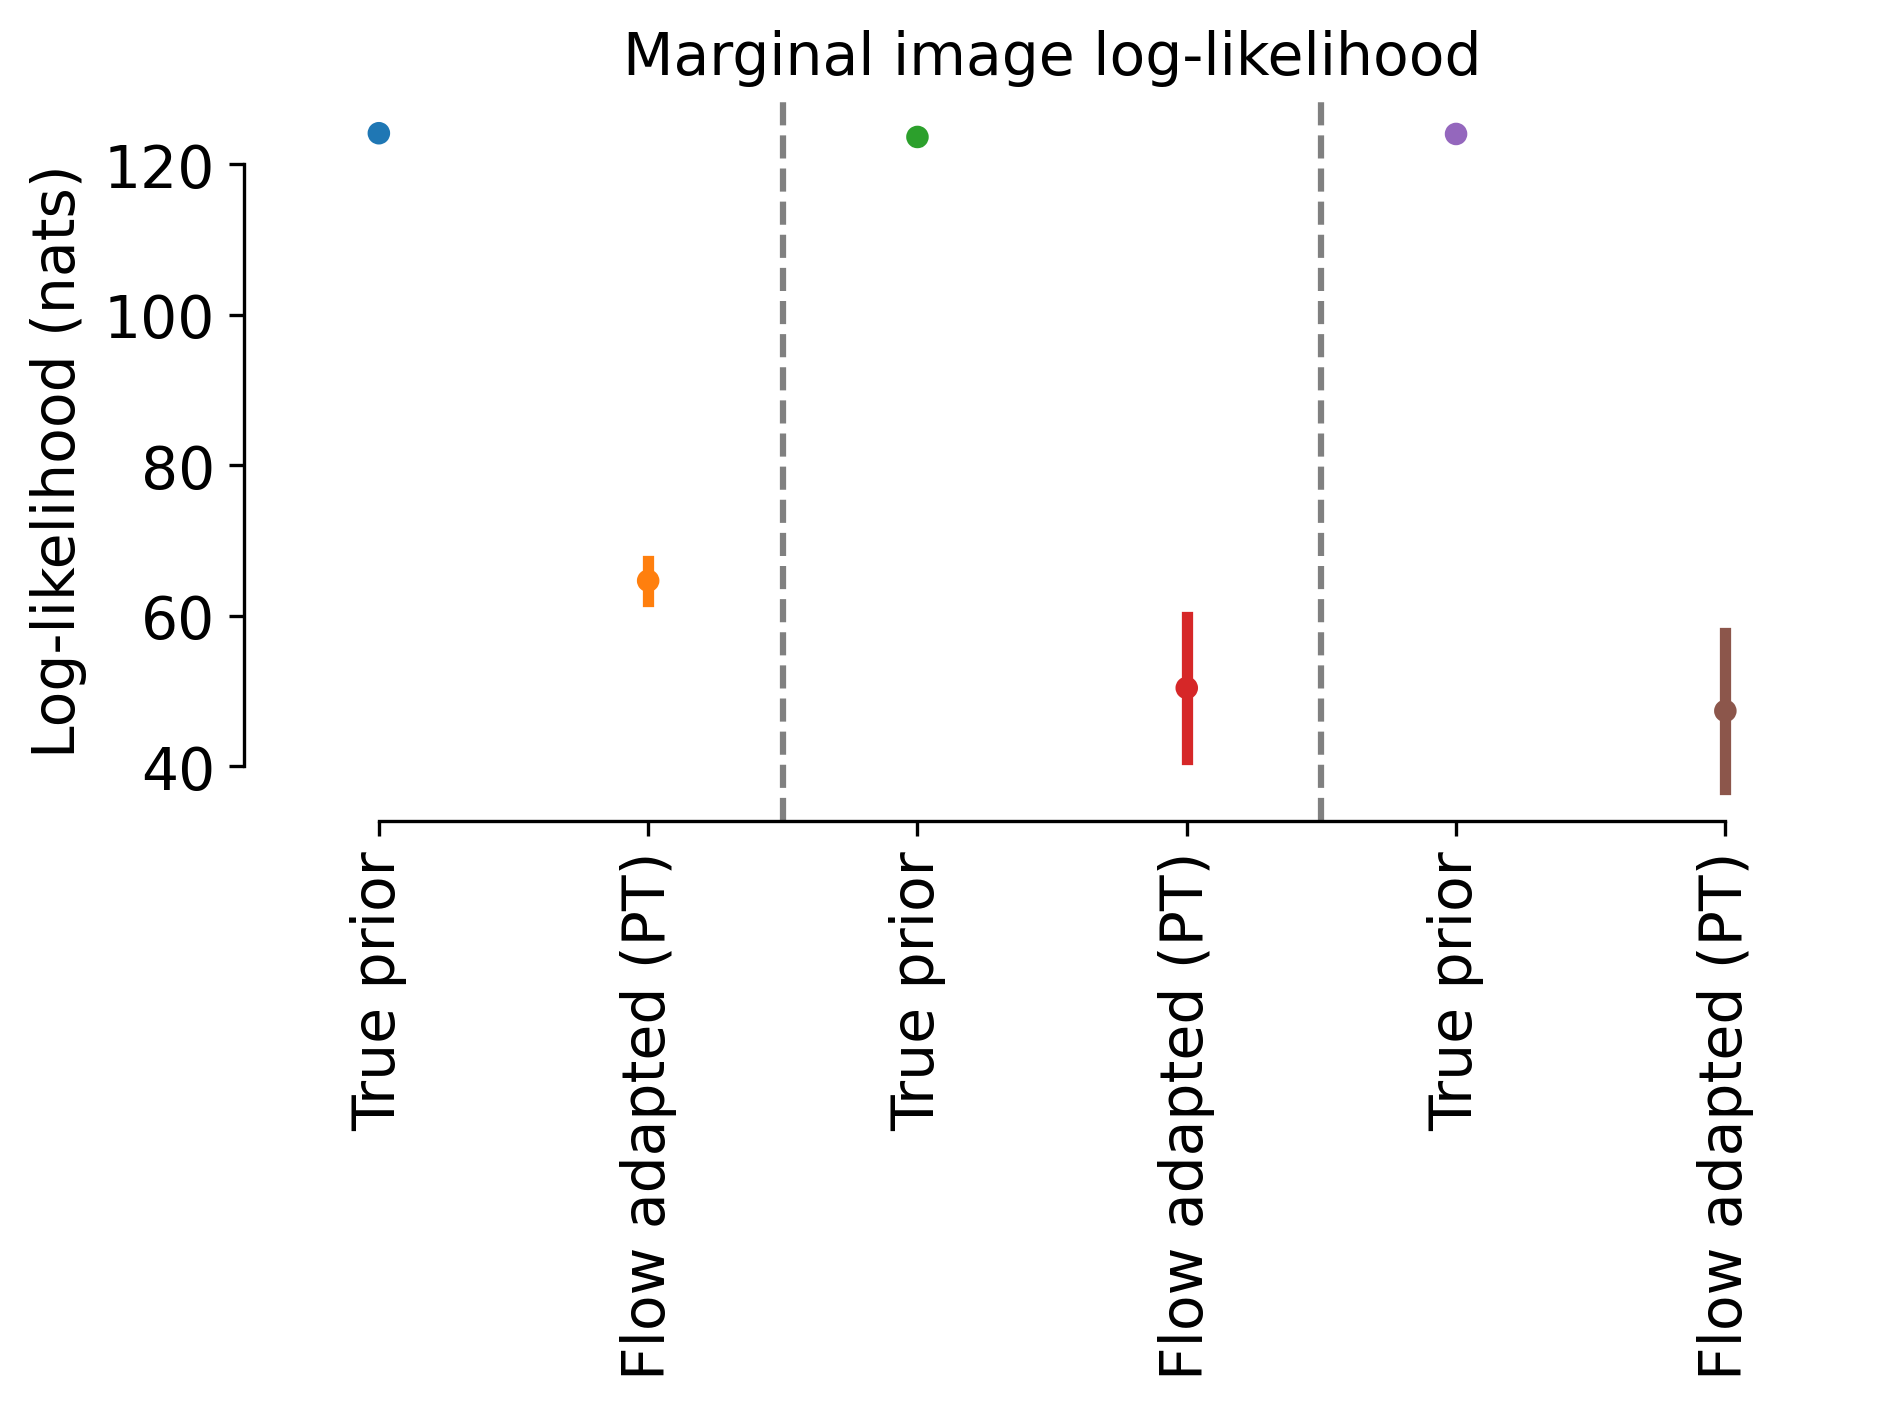

In [8]:
data = [
    true_logl_marg_train.detach().cpu(),
    pt_adpt_flow_logl_marg_train.detach().cpu(),
    true_logl_marg_val.detach().cpu(),
    pt_adpt_flow_logl_marg_val.detach().cpu(),
    true_logl_marg_test.detach().cpu(),
    pt_adpt_flow_logl_marg_test.detach().cpu(),
]
labels = [
    "True prior",

    "Flow adapted (PT)",
    "True prior",
    "Flow adapted (PT)",
    "True prior",
    "Flow adapted (PT)",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=9)
ax = sns.pointplot(
    data=data, ax=ax, errorbar="se", join=False, palette=palette, markers="."
)
# add mean values
# for i, value in enumerate(data):
#     # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
#     # add a red dot
#     ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()